In [1]:


from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

cudnn.benchmark = True
plt.ion()   # interactive mode


/home/mahirwar/anaconda3/envs/amy_plague/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2 

# Classification Task

In [3]:
data_transforms = {'train': A.Compose(
    [
        #A.SmallestMaxSize(max_size=1024),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        #A.RandomCrop(height=256, width=256),
        A.HorizontalFlip(p=0.5),
        #A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),

'val': A.Compose(
    [
        A.SmallestMaxSize(max_size=1024),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        #A.RandomCrop(height=128, width=128),
        #A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
'test': A.Compose(
    [
        A.SmallestMaxSize(max_size=1024),
        #A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        #A.RandomCrop(height=128, width=128),
        #A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        #A.RandomBrightnessContrast(p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
}

class WBG(Dataset):
    def __init__(self, images_filepaths, transform=None):
        self.images_filepaths = images_filepaths
        self.transform = transform

    def __len__(self):
        return len(self.images_filepaths)

    def __getitem__(self, idx):
        image_filepath = self.images_filepaths[idx]
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if os.path.normpath(image_filepath).split(os.sep)[-2] == "Cat":
            label = 1.0
        else:
            label = 0.0
        if self.transform is not None:
            image = self.transform(image=image)["image"]
        return image, label

NameError: name 'Dataset' is not defined

In [162]:
data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images3/"


In [163]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(256),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images3/"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val','test']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [164]:
dataset_sizes

{'train': 33449, 'val': 4181, 'test': 4183}

In [165]:
class_names

['White', 'bg', 'grey']

In [166]:
import os, os.path
DIR = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images3/train"
print(os.listdir(DIR))
for f in os.listdir(DIR):
    d =  os.listdir(os.path.join(DIR,f))
    print(f, len(d))

['grey', 'White', 'bg']
grey 14320
White 14614
bg 4515


torch.Size([4, 3, 256, 256])
(260, 1034, 3)


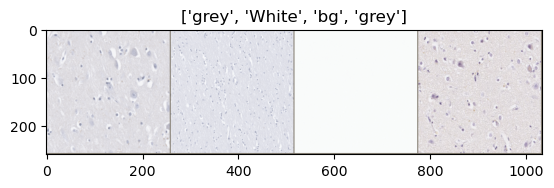

In [167]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    print(inp.shape)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

print(inputs.shape)

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [168]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            #if phase == 'val' and epoch_acc > 0.1*best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [169]:
def visualize_model(model, num_images=20):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            print(labels)
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


In [170]:
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 3)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [171]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.1057 Acc: 0.9662
val Loss: 0.0030 Acc: 0.9990

Epoch 1/24
----------
train Loss: 0.0153 Acc: 0.9956
val Loss: 0.0010 Acc: 1.0000

Epoch 2/24
----------
train Loss: 0.0093 Acc: 0.9972
val Loss: 0.0061 Acc: 0.9981

Epoch 3/24
----------
train Loss: 0.0060 Acc: 0.9982
val Loss: 0.0006 Acc: 1.0000

Epoch 4/24
----------
train Loss: 0.0053 Acc: 0.9984
val Loss: 0.0011 Acc: 0.9995

Epoch 5/24
----------
train Loss: 0.0030 Acc: 0.9992
val Loss: 0.0059 Acc: 0.9981

Epoch 6/24
----------
train Loss: 0.0034 Acc: 0.9990
val Loss: 0.0008 Acc: 1.0000

Epoch 7/24
----------
train Loss: 0.0017 Acc: 0.9995
val Loss: 0.0002 Acc: 1.0000

Epoch 8/24
----------
train Loss: 0.0012 Acc: 0.9996
val Loss: 0.0045 Acc: 1.0000

Epoch 9/24
----------
train Loss: 0.0014 Acc: 0.9996
val Loss: 0.0097 Acc: 1.0000

Epoch 10/24
----------
train Loss: 0.0008 Acc: 0.9998
val Loss: 0.0029 Acc: 0.9998

Epoch 11/24
----------
train Loss: 0.0009 Acc: 0.9997
val Loss: 0.0037 Acc: 0.9993

Ep

tensor([0, 2, 2, 2], device='cuda:0')
(256, 256, 3)


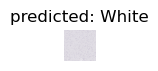

(256, 256, 3)


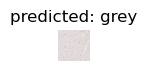

(256, 256, 3)


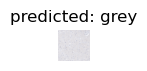

(256, 256, 3)


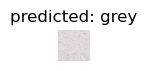

tensor([0, 1, 1, 2], device='cuda:0')
(256, 256, 3)


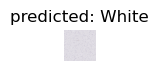

(256, 256, 3)


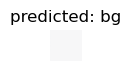

(256, 256, 3)


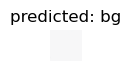

(256, 256, 3)


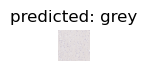

tensor([0, 0, 2, 2], device='cuda:0')
(256, 256, 3)


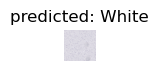

(256, 256, 3)


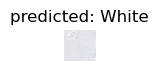

(256, 256, 3)


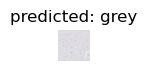

(256, 256, 3)


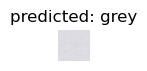

tensor([2, 0, 2, 0], device='cuda:0')
(256, 256, 3)


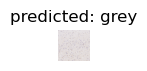

(256, 256, 3)


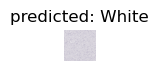

(256, 256, 3)


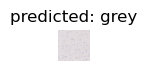

(256, 256, 3)


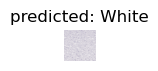

tensor([2, 1, 0, 2], device='cuda:0')
(256, 256, 3)


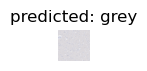

(256, 256, 3)


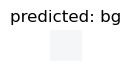

(256, 256, 3)


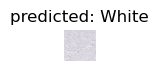

(256, 256, 3)


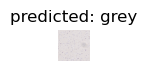

In [172]:
visualize_model(model_ft)

In [205]:
torch.save({"model":model_ft, "state": model_ft.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/model_4_dlb_4_pdd.pth')

In [173]:
from sklearn.metrics import classification_report
def test_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    #fig = plt.figure()
    # White 0, grey 1 bg 2
    map_label = {"White":0, "grey": 2, "bg": 1}
    actual_labels = []
    pred_labels = []
    target_names =  class_names
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)
            #print(labels.tolist())
            actual_labels.extend(labels.tolist())

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            #print(preds)
            pred_labels.extend(preds.tolist())
    #print(actual_labels)
    #print(pred_labels)
    lst3 = [(i,j) for i, j in zip(actual_labels, pred_labels) if i != j]
    print(len(lst3))
    print(classification_report(actual_labels, pred_labels, target_names=target_names))

            #for j in range(inputs.size()[0]):
            #    images_so_far += 1
            #    ax = plt.subplot(num_images//2, 2, images_so_far)
            #    ax.axis('off')
            #    ax.set_title(f'predicted: {class_names[preds[j]]}')
            #    imshow(inputs.cpu().data[j])

            #   if images_so_far == num_images:
            #        model.train(mode=was_training)
            #        return
        #model.train(mode=was_training)

In [174]:
test_model(model_ft, num_images=6)

8
              precision    recall  f1-score   support

       White       1.00      1.00      1.00      1827
          bg       1.00      0.99      1.00       565
        grey       1.00      1.00      1.00      1791

    accuracy                           1.00      4183
   macro avg       1.00      1.00      1.00      4183
weighted avg       1.00      1.00      1.00      4183



# Segmentation Task

In [175]:
import pyvips as Vips
import numpy as np
from Reinhard import Reinhard
import cv2
from PIL import Image

In [176]:
def getVipsInfo(vips_img):
    # # Get bounds-x and bounds-y offeset
    vfields = [f.split('.') for f in vips_img.get_fields()]
    vfields = [f for f in vfields if f[0] == 'openslide']
    vfields = dict([('.'.join(k[1:]), vips_img.get('.'.join(k))) for k in vfields])
    return vfields

def normalization(REF_IMG_PATH):
    print("Init Normalization")
    ref_image = Vips.Image.new_from_file(REF_IMG_PATH)
    normalizer = Reinhard()
    normalizer.fit(ref_image)
    return normalizer

In [177]:
## Load model
#path = 'model_dlb1.pth'
def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

In [204]:
REF_IMG_PATH =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'
#img  =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'
#img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs' 
img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/././PD017_Syn1_CG.svs'
stride = 128
tilesize = 1024
path  ='model_full2.pth'


def predict_crop_class(model_ft, crop):
    crop_array = np.ndarray(buffer=crop.write_to_memory(), dtype=np.uint8, shape=(tilesize, tilesize, crop.bands))
    crop_array = crop_array[:,:,:3]
    #crop_array = torch.from_numpy(crop_array.transpose((2,0,1)))
    #crop_array = crop_array.transpose(2,0,1)
    img = Image.fromarray(crop_array.astype('uint8'), 'RGB')
    #img = Image.fromarray(np.uint8(crop_array.transpose((2,0,1)))).convert('RGB')
    transformed_img = data_transforms["test"](img)
    transformed_img = torch.unsqueeze(transformed_img, dim=0)
    outputs = model_ft(transformed_img.to(device).float())
    _, preds = torch.max(outputs, 1)
    return preds.tolist()


def construct_wsi_mask(stride, tilesize,REF_IMG_PATH,img):
    normalizer = normalization(REF_IMG_PATH)
    vips_img = Vips.Image.new_from_file(img, level=0)
    vips_img = normalizer.transform(vips_img)
    vinfo = getVipsInfo(vips_img)
    orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
    vips_array = np.ndarray(buffer=vips_img.write_to_memory(), dtype=np.uint8, shape=(vips_img.height, vips_img.width, vips_img.bands))
    vips_array = vips_array[:,:,:3]
    vips_array_copy =vips_array.copy()
    masked_image = np.zeros((orig_h,orig_w,3))
    count_predictions = {"white":0,"grey":0,"bg":0}
    #model_ft =  load_saved_model(path)
    for y_val in range(0, orig_h-stride, stride):
        for x_val in range(0, orig_w-stride, stride): 
                if y_val + tilesize < orig_h and x_val + tilesize < orig_w:
                    crop = vips_img.crop(x_val, y_val, tilesize, tilesize)
                    crop_pred =  predict_crop_class(model_ft, crop)
                    print(crop_pred)
                    if crop_pred==[0]:
                        count_predictions["white"] = count_predictions["white"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [0,0,255]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(0,0,255),30)
                    if crop_pred==[1]:
                        count_predictions["bg"] = count_predictions["bg"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [255,0,0]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(255,0,0),30)
                    if crop_pred==[2]:
                        count_predictions["grey"] = count_predictions["grey"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [0,255,0]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(0,255,0),30)
    return masked_image, vips_array_copy, count_predictions

def print_thumnail(img1):
    th1 = Image.fromarray(img1.astype(np.uint8))
    th1.thumbnail((1000,1000))
    return th1
        

In [206]:
masked_image, vips_array_copy, count_predictions = construct_wsi_mask(stride, tilesize,REF_IMG_PATH,img)

Init Normalization
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[2]
[1]
[1]
[1]
[1]
[1]
[1]
[0]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[0]
[0]
[0]
[0]
[0]
[0]
[2]
[2]
[2]
[0]
[0]
[

In [202]:
count_predictions

{'white': 5604, 'grey': 7721, 'bg': 2355}

In [143]:
count_predictions

{'white': 2177, 'grey': 1261, 'bg': 3218}

In [146]:
vips_array_copy1 = vips_array_copy

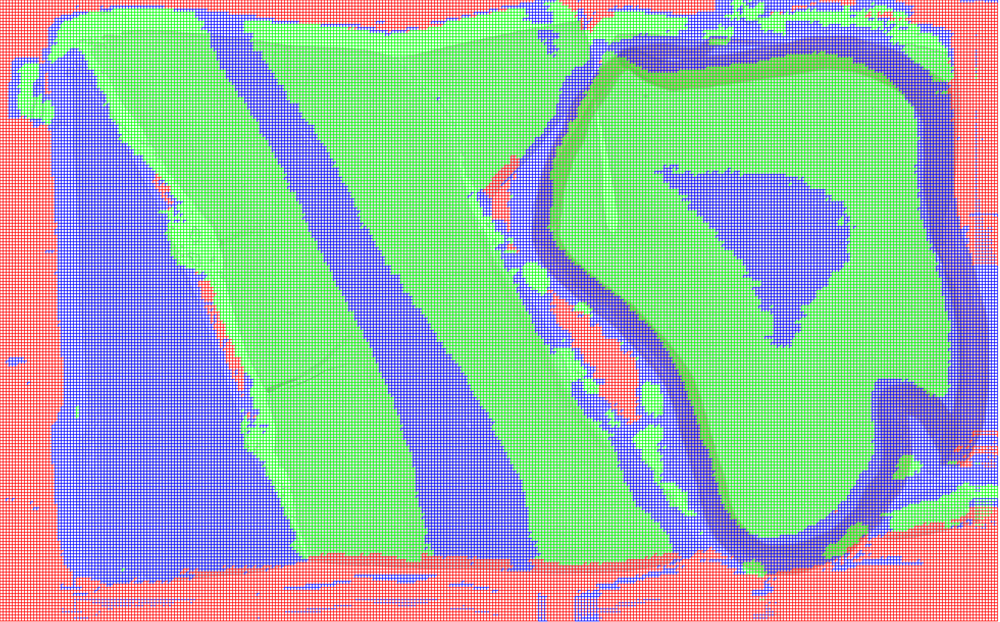

In [207]:
print_thumnail(vips_array_copy)

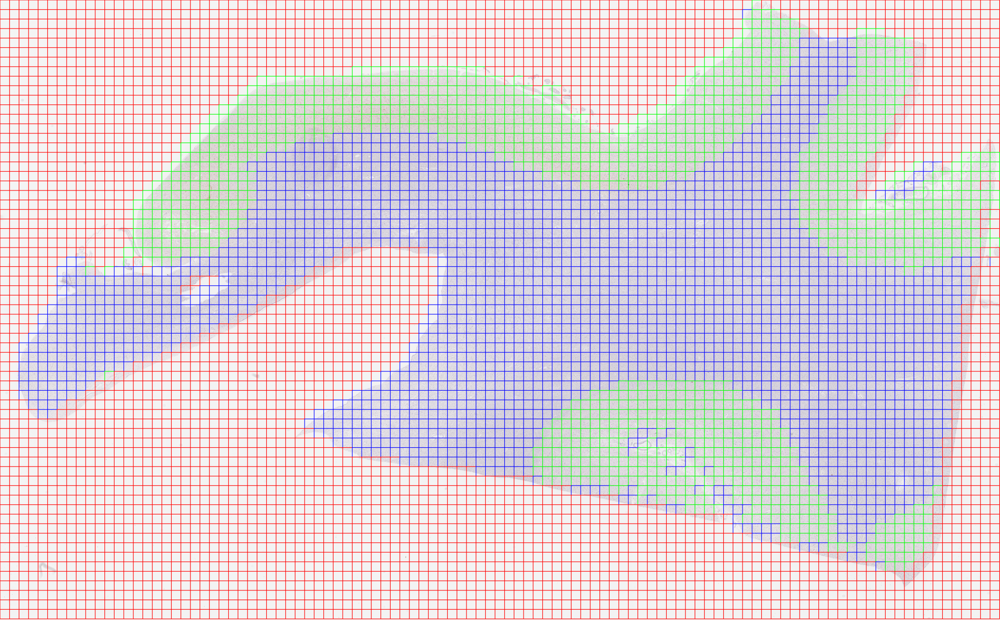

In [149]:
print_thumnail(vips_array_copy)

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

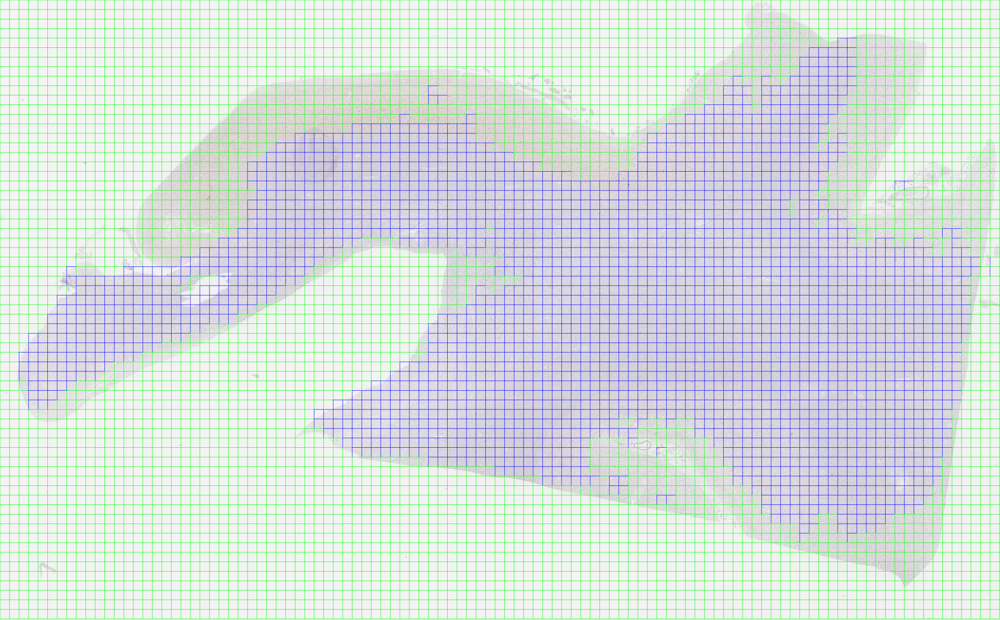

In [20]:
th1.thumbnail((1000,1000))
th1